In [54]:
import sys
import subprocess

packages = [
    "torch",
    "torchvision",
    "medmnist",
    "numpy",
    "matplotlib",
    "scikit-learn",
    "tqdm"
]

for p in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", p])

In [33]:
import numpy as np
import torch
from torch.utils.data import DataLoader
import torchvision.transforms as T
import matplotlib.pyplot as plt
from tqdm import tqdm

import medmnist
from medmnist import INFO

data_flag = "breastmnist"
info = INFO[data_flag]

DataClass = getattr(medmnist, info["python_class"])

info

{'python_class': 'BreastMNIST',
 'description': 'The BreastMNIST is based on a dataset of 780 breast ultrasound images. It is categorized into 3 classes: normal, benign, and malignant. As we use low-resolution images, we simplify the task into binary classification by combining normal and benign as positive and classifying them against malignant as negative. We split the source dataset with a ratio of 7:1:2 into training, validation and test set. The source images of 1×500×500 are resized into 1×28×28.',
 'url': 'https://zenodo.org/records/10519652/files/breastmnist.npz?download=1',
 'MD5': '750601b1f35ba3300ea97c75c52ff8f6',
 'url_64': 'https://zenodo.org/records/10519652/files/breastmnist_64.npz?download=1',
 'MD5_64': '742edef2a1fd1524b2efff4bd7ba9364',
 'url_128': 'https://zenodo.org/records/10519652/files/breastmnist_128.npz?download=1',
 'MD5_128': '363e4b3f8d712e9b5de15470a2aaadf1',
 'url_224': 'https://zenodo.org/records/10519652/files/breastmnist_224.npz?download=1',
 'MD5_224

In [34]:
import os

archivo_subido = "/content/breastmnist (1).npz"
archivo_final = "/content/breastmnist.npz"

if os.path.exists(archivo_subido):
    os.rename(archivo_subido, archivo_final)

print("Base de datos lista:", os.path.exists(archivo_final))

Base de datos lista: True


In [35]:
transform_basic = T.Compose([
    T.ToTensor()
])

train_dataset = DataClass(
    split="train",
    transform=transform_basic,
    download=True,
    root="/content"
)

val_dataset = DataClass(
    split="val",
    transform=transform_basic,
    download=True,
    root="/content"
)

test_dataset = DataClass(
    split="test",
    transform=transform_basic,
    download=True,
    root="/content"
)

len(train_dataset), len(val_dataset), len(test_dataset)

(546, 78, 156)

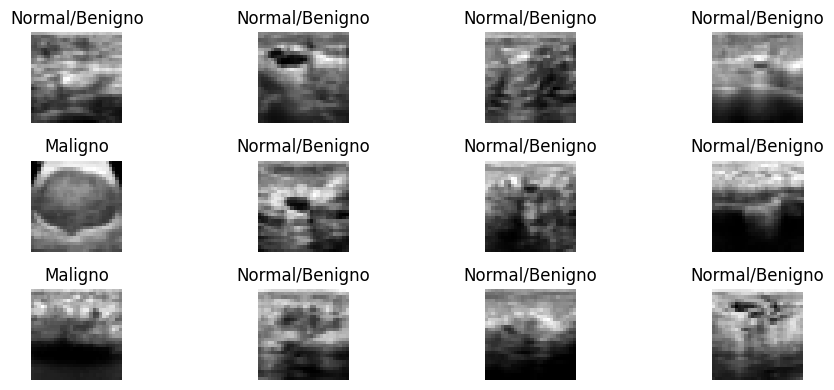

In [36]:
def show_batch(dataset, n=12):
    plt.figure(figsize=(10, 4))

    for i in range(n):
        x, y = dataset[i]

        plt.subplot(3, 4, i+1)

        img = x.squeeze(0)

        plt.imshow(img, cmap="gray")

        etiqueta = int(y.item())

        if etiqueta == 0:
            plt.title("Maligno")
        else:
            plt.title("Normal/Benigno")

        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_batch(train_dataset, n=12)

In [37]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

device

device(type='cpu')

In [38]:
batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

next(iter(train_loader))[0].shape, next(iter(train_loader))[1].shape

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


(torch.Size([128, 1, 28, 28]), torch.Size([128, 1]))

In [39]:
import torch.nn as nn

num_classes = len(info["label"])

class SimpleCNN(nn.Module):

    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.10),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.15),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.25),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


model_scratch = SimpleCNN(num_classes).to(device)

In [40]:



# ==========================================
# CELDA 9 - FUNCIONES DE ENTRENAMIENTO
# Y EVALUACIÓN
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

import numpy as np
import torch


# ------------------------------------------
# Convertir logits en probabilidades
# ------------------------------------------

def logits_to_probs(logits):
    return torch.softmax(logits, dim=1)[:, 1]


# ------------------------------------------
# Evaluación del modelo
# ------------------------------------------

@torch.no_grad()
def evaluate(model, loader, criterion=None):

    model.eval()

    all_labels = []
    all_probs = []
    all_preds = []

    losses = []

    for x, y in loader:

        x = x.to(device)

        y = y.to(device).long().view(-1)

        # Predicción
        logits = model(x)

        # Calcular pérdida de validación
        if criterion is not None:

            loss = criterion(
                logits,
                y
            )

            losses.append(
                loss.item()
            )

        # Probabilidad de la clase positiva
        probs = logits_to_probs(
            logits
        )

        # Clasificación usando umbral 0.5
        preds = (
            probs >= 0.5
        ).long()

        # Guardar resultados
        all_labels.append(
            y.cpu().numpy()
        )

        all_probs.append(
            probs.cpu().numpy()
        )

        all_preds.append(
            preds.cpu().numpy()
        )


    # Unir resultados
    y_true = np.concatenate(
        all_labels
    )

    y_prob = np.concatenate(
        all_probs
    )

    y_pred = np.concatenate(
        all_preds
    )


    # Accuracy
    acc = accuracy_score(
        y_true,
        y_pred
    )


    # ROC-AUC
    auc = roc_auc_score(
        y_true,
        y_prob
    )


    # Pérdida promedio de validación
    val_loss = (
        float(np.mean(losses))
        if len(losses) > 0
        else None
    )


    return (
        acc,
        auc,
        y_true,
        y_pred,
        y_prob,
        val_loss
    )


# ------------------------------------------
# Entrenamiento de una época
# ------------------------------------------

def train_one_epoch(
    model,
    loader,
    optimizer,
    criterion
):

    model.train()

    losses = []


    for x, y in loader:

        x = x.to(device)

        y = y.to(device).long().view(-1)


        # Reiniciar gradientes
        optimizer.zero_grad()


        # Predicción
        logits = model(x)


        # Calcular pérdida
        loss = criterion(
            logits,
            y
        )


        # Backpropagation
        loss.backward()


        # Actualizar pesos
        optimizer.step()


        # Guardar pérdida
        losses.append(
            loss.item()
        )


    # Pérdida promedio de entrenamiento
    return float(
        np.mean(losses)
    )

In [41]:



# ==========================================
# CELDA 10 - ENTRENAMIENTO CNN DESDE CERO
# ==========================================

# Obtener las etiquetas del conjunto de entrenamiento
labels_train = []

for _, y in train_dataset:
    labels_train.append(int(y.item()))


# Cantidad de imágenes por clase
class_counts = np.bincount(labels_train)

print("Cantidad por clase:", class_counts)


# Calcular pesos para compensar el desbalance
class_weights = len(labels_train) / (2.0 * class_counts)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)

print("Pesos de las clases:", class_weights)


# Función de pérdida balanceada
criterion = nn.CrossEntropyLoss(
    weight=class_weights
)


# Optimizador
# Learning rate menor para un aprendizaje más gradual
# Weight decay para mejorar la regularización
optimizer = torch.optim.AdamW(
    model_scratch.parameters(),
    lr=3e-5,
    weight_decay=2e-3
)


# Número de épocas
epochs = 100


# Historial de entrenamiento
history_scratch = {
    "train_loss": [],
    "val_loss": [],
    "val_acc": [],
    "val_auc": []
}


# ==========================================
# ENTRENAMIENTO
# ==========================================

for epoch in range(1, epochs + 1):

    # Entrenamiento
    train_loss = train_one_epoch(
        model_scratch,
        train_loader,
        optimizer,
        criterion
    )

    # Validación
    val_acc, val_auc, _, _, _, val_loss = evaluate(
        model_scratch,
        val_loader,
        criterion
    )


    # Guardar resultados
    history_scratch["train_loss"].append(train_loss)
    history_scratch["val_loss"].append(val_loss)
    history_scratch["val_acc"].append(val_acc)
    history_scratch["val_auc"].append(val_auc)


    # Mostrar resultados de cada época
    print(
        f"Epoch {epoch:03d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_loss:.4f} | "
        f"val_acc={val_acc:.4f} | "
        f"val_auc={val_auc:.4f}"
    )

Cantidad por clase: [147 399]
Pesos de las clases: tensor([1.8571, 0.6842])
Epoch 001 | train_loss=0.7226 | val_loss=0.6944 | val_acc=0.2692 | val_auc=0.4486


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 002 | train_loss=0.7136 | val_loss=0.6941 | val_acc=0.2692 | val_auc=0.4353


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 003 | train_loss=0.7019 | val_loss=0.6938 | val_acc=0.2692 | val_auc=0.4586


...

Epoch 098 | train_loss=0.5521 | val_loss=0.5274 | val_acc=0.6923 | val_auc=0.8287


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 099 | train_loss=0.5807 | val_loss=0.5294 | val_acc=0.6923 | val_auc=0.8296


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 100 | train_loss=0.5908 | val_loss=0.5286 | val_acc=0.6923 | val_auc=0.8304


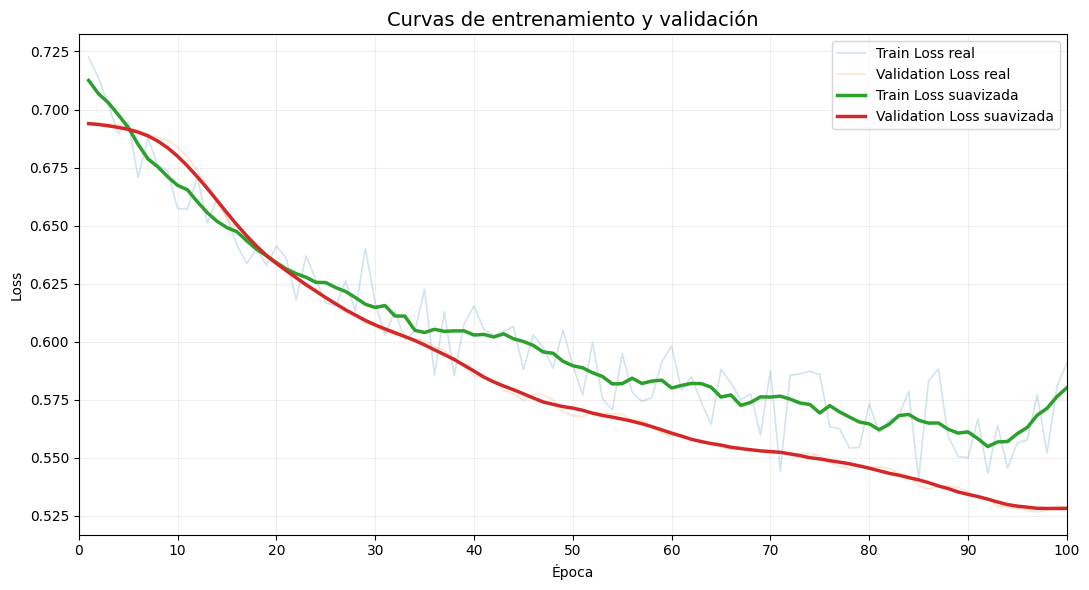

In [42]:
import numpy as np
import matplotlib.pyplot as plt



# SUAVIZADO DE LAS CURVAS


def suavizar_curva(datos, ventana=9):
    datos = np.array(datos, dtype=float)

    kernel = np.ones(ventana) / ventana

    datos_pad = np.pad(
        datos,
        (ventana // 2, ventana // 2),
        mode="edge"
    )

    return np.convolve(
        datos_pad,
        kernel,
        mode="valid"
    )


# Datos reales
train_real = np.array(
    history_scratch["train_loss"]
)

val_real = np.array(
    history_scratch["val_loss"]
)


# Datos suavizados
train_suave = suavizar_curva(
    train_real,
    ventana=9
)

val_suave = suavizar_curva(
    val_real,
    ventana=9
)


# Épocas
epocas = np.arange(
    1,
    len(train_real) + 1
)



# GRÁFICA


plt.figure(figsize=(11, 6))


# Curvas REALES
plt.plot(
    epocas,
    train_real,
    alpha=0.20,
    linewidth=1.2,
    label="Train Loss real"
)

plt.plot(
    epocas,
    val_real,
    alpha=0.20,
    linewidth=1.2,
    label="Validation Loss real"
)


# Curvas SUAVIZADAS
plt.plot(
    epocas,
    train_suave,
    linewidth=2.5,
    label="Train Loss suavizada"
)

plt.plot(
    epocas,
    val_suave,
    linewidth=2.5,
    label="Validation Loss suavizada"
)



# PRESENTACIÓN


plt.title(
    "Curvas de entrenamiento y validación",
    fontsize=14
)

plt.xlabel("Época")
plt.ylabel("Loss")

plt.xlim(
    1,
    len(epocas)
)

plt.xticks(
    np.arange(0, len(epocas) + 1, 10)
)

plt.legend()

plt.grid(
    alpha=0.20
)

plt.tight_layout()

plt.show()

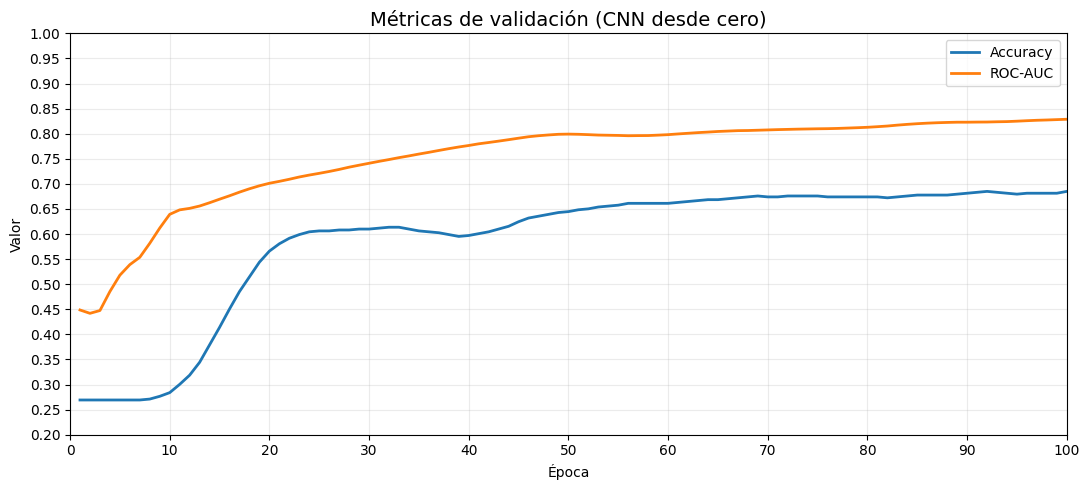

In [43]:
import numpy as np
import matplotlib.pyplot as plt


# Función para suavizar las curvas
def suavizar(valores, ventana=7):
    valores = np.array(valores, dtype=float)
    resultado = []

    for i in range(len(valores)):
        inicio = max(0, i - ventana + 1)
        resultado.append(
            np.mean(valores[inicio:i+1])
        )

    return np.array(resultado)


# Suavizar Accuracy y ROC-AUC
acc_suave = suavizar(
    history_scratch["val_acc"],
    ventana=7
)

auc_suave = suavizar(
    history_scratch["val_auc"],
    ventana=7
)


# Crear gráfica
plt.figure(figsize=(11, 5))


# Accuracy
plt.plot(
    range(1, len(acc_suave) + 1),
    acc_suave,
    label="Accuracy",
    linewidth=2
)


# ROC-AUC
plt.plot(
    range(1, len(auc_suave) + 1),
    auc_suave,
    label="ROC-AUC",
    linewidth=2
)


# Título
plt.title(
    "Métricas de validación (CNN desde cero)",
    fontsize=14
)

plt.xlabel("Época")
plt.ylabel("Valor")


# Escala de las épocas
plt.xlim(1, 100)

plt.xticks(
    np.arange(0, 101, 10)
)


# Escala vertical ampliada
# Ahora podremos observar las métricas desde valores bajos
plt.ylim(0.20, 1.00)

plt.yticks(
    np.arange(0.20, 1.01, 0.05)
)


# Leyenda
plt.legend()


# Cuadrícula
plt.grid(alpha=0.25)


plt.tight_layout()
plt.show()

In [44]:
test_acc, test_auc, y_true, y_pred, y_prob, _ = evaluate(
    model_scratch,
    test_loader
)


print(f"Test accuracy: {test_acc:.4f}")
print(f"Test ROC-AUC:  {test_auc:.4f}")

print()

print(
    classification_report(
        y_true,
        y_pred,
        target_names=["Maligno", "Normal/Benigno"],
        digits=4
    )
)

cm = confusion_matrix(
    y_true,
    y_pred
)

cm

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Test accuracy: 0.6667
Test ROC-AUC:  0.8091

                precision    recall  f1-score   support

       Maligno     0.4342    0.7857    0.5593        42
Normal/Benigno     0.8875    0.6228    0.7320       114

      accuracy                         0.6667       156
     macro avg     0.6609    0.7043    0.6456       156
  weighted avg     0.7655    0.6667    0.6855       156



array([[33,  9],
       [43, 71]])

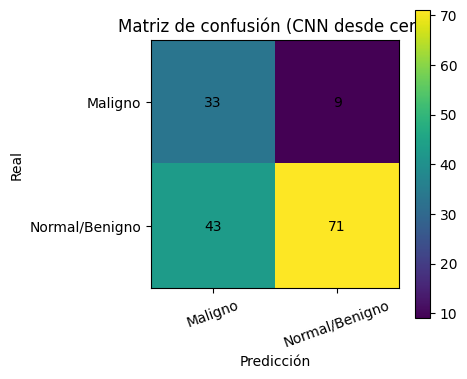

In [45]:
plt.figure(figsize=(4, 4))

plt.imshow(cm)

plt.title("Matriz de confusión (CNN desde cero)")

plt.xlabel("Predicción")
plt.ylabel("Real")

plt.xticks(
    [0, 1],
    ["Maligno", "Normal/Benigno"],
    rotation=20
)

plt.yticks(
    [0, 1],
    ["Maligno", "Normal/Benigno"]
)

for i in range(2):
    for j in range(2):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()

plt.show()

In [46]:
transform_aug = T.Compose([
    T.RandomRotation(degrees=10),
    T.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05)
    ),
    T.ToTensor()
])

train_dataset_aug = DataClass(
    split="train",
    transform=transform_aug,
    download=False,
    root="/content"
)

train_loader_aug = DataLoader(
    train_dataset_aug,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

In [47]:
model_aug = SimpleCNN(
    num_classes=num_classes
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model_aug.parameters(),
    lr=1e-3
)

epochs = 6

history_aug = {
    "train_loss": [],
    "val_acc": [],
    "val_auc": []
}

for epoch in range(1, epochs + 1):

    train_loss = train_one_epoch(
        model_aug,
        train_loader_aug,
        optimizer,
        criterion
    )

    val_acc, val_auc, _, _, _, _ = evaluate(
        model_aug,
        val_loader
    )

    history_aug["train_loss"].append(train_loss)
    history_aug["val_acc"].append(val_acc)
    history_aug["val_auc"].append(val_auc)

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_acc={val_acc:.4f} | "
        f"val_auc={val_auc:.4f}"
    )


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 01 | train_loss=0.6255 | val_acc=0.7308 | val_auc=0.6324


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 02 | train_loss=0.5479 | val_acc=0.7308 | val_auc=0.6115


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


...

Epoch 04 | train_loss=0.5984 | val_acc=0.7179 | val_auc=0.6550


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 05 | train_loss=0.5437 | val_acc=0.6667 | val_auc=0.6299


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 06 | train_loss=0.5149 | val_acc=0.6667 | val_auc=0.6558


In [48]:
test_acc_aug, test_auc_aug, _, _, _, _ = evaluate(
    model_aug,
    test_loader
)

print(
    f"Sin augmentation | "
    f"test_acc={test_acc:.4f} | "
    f"test_auc={test_auc:.4f}"
)

print(
    f"Con augmentation | "
    f"test_acc={test_acc_aug:.4f} | "
    f"test_auc={test_auc_aug:.4f}"
)

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Sin augmentation | test_acc=0.6667 | test_auc=0.8091
Con augmentation | test_acc=0.7372 | test_auc=0.6798


In [49]:
import torchvision.models as models

transform_tl_train = T.Compose([
    T.Resize((224, 224)),
    T.RandomRotation(degrees=10),
    T.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05)
    ),
    T.ToTensor(),
    T.Lambda(
        lambda x: x.repeat(3, 1, 1)
    )
])

transform_tl_eval = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Lambda(
        lambda x: x.repeat(3, 1, 1)
    )
])

train_dataset_tl = DataClass(
    split="train",
    transform=transform_tl_train,
    download=False,
    root="/content"
)

val_dataset_tl = DataClass(
    split="val",
    transform=transform_tl_eval,
    download=False,
    root="/content"
)

test_dataset_tl = DataClass(
    split="test",
    transform=transform_tl_eval,
    download=False,
    root="/content"
)

train_loader_tl = DataLoader(
    train_dataset_tl,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader_tl = DataLoader(
    val_dataset_tl,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader_tl = DataLoader(
    test_dataset_tl,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

next(iter(train_loader_tl))[0].shape

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


torch.Size([64, 3, 224, 224])

In [50]:
resnet = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)

in_features = resnet.fc.in_features

resnet.fc = nn.Linear(
    in_features,
    num_classes
)

resnet = resnet.to(device)

for name, param in resnet.named_parameters():
    param.requires_grad = False

for param in resnet.fc.parameters():
    param.requires_grad = True

resnet

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [51]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    resnet.fc.parameters(),
    lr=1e-3
)

epochs = 4

history_tl_stage1 = {
    "train_loss": [],
    "val_acc": [],
    "val_auc": []
}

for epoch in range(1, epochs + 1):

    train_loss = train_one_epoch(
        resnet,
        train_loader_tl,
        optimizer,
        criterion
    )

    val_acc, val_auc, _, _, _, _ = evaluate(
        resnet,
        val_loader_tl
    )

    history_tl_stage1["train_loss"].append(train_loss)
    history_tl_stage1["val_acc"].append(val_acc)
    history_tl_stage1["val_auc"].append(val_auc)

    print(
        f"Stage1 Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_acc={val_acc:.4f} | "
        f"val_auc={val_auc:.4f}"
    )

Stage1 Epoch 01 | train_loss=0.6210 | val_acc=0.7436 | val_auc=0.5831


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Stage1 Epoch 02 | train_loss=0.5884 | val_acc=0.7308 | val_auc=0.5071


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Stage1 Epoch 03 | train_loss=0.5525 | val_acc=0.7308 | val_auc=0.5071


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Stage1 Epoch 04 | train_loss=0.5263 | val_acc=0.7308 | val_auc=0.5581


In [52]:
for name, param in resnet.named_parameters():

    if name.startswith("layer4") or name.startswith("fc"):
        param.requires_grad = True

trainable_params = [
    p for p in resnet.parameters()
    if p.requires_grad
]

len(trainable_params)

17

In [31]:
optimizer = torch.optim.Adam(
    trainable_params,
    lr=1e-4
)

epochs = 4

history_tl_stage2 = {
    "train_loss": [],
    "val_acc": [],
    "val_auc": []
}

for epoch in range(1, epochs + 1):

    train_loss = train_one_epoch(
        resnet,
        train_loader_tl,
        optimizer,
        criterion
    )

    val_acc, val_auc, _, _, _, _ = evaluate(
        resnet,
        val_loader_tl
    )

    history_tl_stage2["train_loss"].append(train_loss)
    history_tl_stage2["val_acc"].append(val_acc)
    history_tl_stage2["val_auc"].append(val_auc)

    print(
        f"Stage2 Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_acc={val_acc:.4f} | "
        f"val_auc={val_auc:.4f}"
    )


Stage2 Epoch 01 | train_loss=0.0925 | val_acc=0.8205 | val_auc=0.9315


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Stage2 Epoch 02 | train_loss=0.0827 | val_acc=0.9231 | val_auc=0.9424


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Stage2 Epoch 03 | train_loss=0.0670 | val_acc=0.8333 | val_auc=0.9256


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Stage2 Epoch 04 | train_loss=0.0680 | val_acc=0.8974 | val_auc=0.9323


In [55]:
test_acc_tl, test_auc_tl, y_true_tl, y_pred_tl, y_prob_tl, _ = evaluate(
    resnet,
    test_loader_tl
)

print(
    f"Transfer learning | "
    f"test_acc={test_acc_tl:.4f} | "
    f"test_auc={test_auc_tl:.4f}"
)

print()

print(
    classification_report(
        y_true_tl,
        y_pred_tl,
        target_names=["Maligno", "Normal/Benigno"],
        digits=4
    )
)

cm_tl = confusion_matrix(
    y_true_tl,
    y_pred_tl
)

cm_tl

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Transfer learning | test_acc=0.7308 | test_auc=0.6671

                precision    recall  f1-score   support

       Maligno     0.0000    0.0000    0.0000        42
Normal/Benigno     0.7308    1.0000    0.8444       114

      accuracy                         0.7308       156
     macro avg     0.3654    0.5000    0.4222       156
  weighted avg     0.5340    0.7308    0.6171       156



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


array([[  0,  42],
       [  0, 114]])

In [56]:
print("RESUMEN DE RESULTADOS EN TEST")
print()

print(
    f"CNN desde cero (sin aug)  | "
    f"acc={test_acc:.4f} | "
    f"auc={test_auc:.4f}"
)

print(
    f"CNN desde cero (con aug)  | "
    f"acc={test_acc_aug:.4f} | "
    f"auc={test_auc_aug:.4f}"
)

print(
    f"Transfer learning (ResNet) | "
    f"acc={test_acc_tl:.4f} | "
    f"auc={test_auc_tl:.4f}"
)

RESUMEN DE RESULTADOS EN TEST

CNN desde cero (sin aug)  | acc=0.6667 | auc=0.8091
CNN desde cero (con aug)  | acc=0.7372 | auc=0.6798
Transfer learning (ResNet) | acc=0.7308 | auc=0.6671


In [57]:
import torch

def grad_cam(
    model,
    image_tensor,
    target_class=None
):

    model.eval()

    image_tensor = image_tensor.to(device)

    activations = {}
    gradients = {}

    def forward_hook(module, inp, out):
        activations["value"] = out

    def backward_hook(module, grad_in, grad_out):
        gradients["value"] = grad_out[0]

    handle_fwd = model.layer4.register_forward_hook(
        forward_hook
    )

    handle_bwd = model.layer4.register_full_backward_hook(
        backward_hook
    )

    logits = model(
        image_tensor.unsqueeze(0)
    )

    if target_class is None:
        target_class = int(
            torch.argmax(
                logits,
                dim=1
            ).item()
        )

    score = logits[0, target_class]

    model.zero_grad()

    score.backward()

    act = activations["value"][0]
    grad = gradients["value"][0]

    weights = torch.mean(
        grad,
        dim=(1, 2)
    )

    cam = torch.sum(
        weights[:, None, None] * act,
        dim=0
    )

    cam = torch.relu(cam)

    cam = cam - cam.min()

    cam = cam / (
        cam.max() + 1e-8
    )

    handle_fwd.remove()
    handle_bwd.remove()

    return (
        cam.detach().cpu().numpy(),
        target_class
    )

/tmp/ipykernel_957/955318872.py:46: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  score.backward()


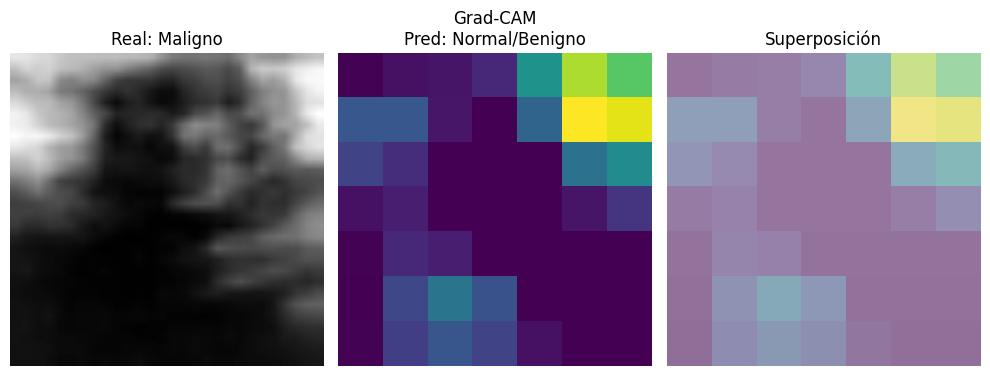

In [58]:
idx = 0

x, y = test_dataset_tl[idx]

cam, pred_class = grad_cam(
    resnet,
    x
)

img = x[0].numpy()

label_real = int(y.item())

nombres = {
    0: "Maligno",
    1: "Normal/Benigno"
}

plt.figure(figsize=(10, 4))


plt.subplot(1, 3, 1)

plt.imshow(
    img,
    cmap="gray"
)

plt.title(
    f"Real: {nombres[label_real]}"
)

plt.axis("off")


plt.subplot(1, 3, 2)

plt.imshow(cam)

plt.title(
    f"Grad-CAM\nPred: {nombres[pred_class]}"
)

plt.axis("off")


plt.subplot(1, 3, 3)

plt.imshow(
    img,
    cmap="gray"
)

plt.imshow(
    cam,
    alpha=0.5
)

plt.title("Superposición")

plt.axis("off")


plt.tight_layout()

plt.show()

In [ ]:
import os

os.makedirs(
    "models",
    exist_ok=True
)

torch.save(
    model_scratch.state_dict(),
    "models/cnn_scratch.pth"
)

torch.save(
    model_aug.state_dict(),
    "models/cnn_aug.pth"
)

torch.save(
    resnet.state_dict(),
    "models/resnet_transfer.pth"
)

[
    "models/cnn_scratch.pth",
    "models/cnn_aug.pth",
    "models/resnet_transfer.pth"
]